## 04 작업내용
1. 라벨링 데이터 로드
2. RUL 음수 해결 컬럼 추가
3. invalid cycle 처리
4. capacity fade 분석
5. SoH 분석
6. RUL 분석
7. 분석용 파일 저장

## 04 체크사항
1. battery_cycles_labeled 파일을 정상 로드했는가?
2. row 수가 936개인가?
3. eol_cycle이 127로 유지되는가?
4. 기존 rul에는 음수 값이 존재하는가?
5. rul_clipped에는 음수 값이 없는가?
6. cycle > eol_cycle인 row는 post_eol=True인가?
7. life_stage 값이 pre_eol/eol/post_eol로만 구성되는가?
8. valid cycle 기준 SoH min/max가 03 결과와 일치하는가?
9. capacity/SoH/RUL 그래프가 정상적으로 그려지는가?
10. analysis CSV와 Parquet이 저장됐는가?
11. CSV와 Parquet을 다시 읽었을 때 shape과 컬럼명이 같은가?

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
PROJECT_ROOT = Path("..").resolve()

CSV_INPUT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "csv"
    / "battery_cycles_labeled.csv"
)

PARQUET_INPUT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "paraquet"
    / "battery_cycles_labeled.parquet"
)

CSV_OUTPUT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "csv"
    / "battery_cycles_analysis.csv"
)

PARQUET_OUTPUT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "paraquet"
    / "battery_cycles_analysis.parquet"
)

In [3]:
# 데이터 로드 및 검증

if PARQUET_INPUT_PATH.exists():
    battery_cycles = pd.read_parquet(
        PARQUET_INPUT_PATH
    )
else:
    battery_cycles = pd.read_csv(
        CSV_INPUT_PATH
    )

required_cols = [
    "cell_id",
    "cycle",
    "capacity_ah",
    "initial_capacity",
    "soh",
    "eol_threshold",
    "eol_cycle",
    "rul",
    "rul_clipped",
    "is_censored",
    "cycle_type",
    "is_modeling_cycle",
]

missing_cols = [
    column
    for column in required_cols
    if column not in battery_cycles.columns
]

assert not missing_cols, (
    f"Missing columns: {missing_cols}"
)

battery_cycles = (
    battery_cycles
    .sort_values("cycle")
    .reset_index(drop=True)
)

print("input shape:", battery_cycles.shape)
print(
    battery_cycles["cycle_type"]
    .value_counts()
)

input shape: (886, 38)
cycle_type
standard_full_cycle    868
nonstandard_cycle       14
invalid                  4
Name: count, dtype: int64


In [4]:
# Modeling Cycle 및 EOL 확인
modeling_mask = (
    battery_cycles["is_modeling_cycle"]
    .fillna(False)
    .astype(bool)
)

excluded_mask = ~modeling_mask

eol_values = (
    battery_cycles["eol_cycle"]
    .dropna()
    .astype(int)
    .unique()
)

assert len(eol_values) == 1

eol_cycle = int(eol_values[0])

is_censored = bool(
    battery_cycles[
        "is_censored"
    ].iloc[0]
)

initial_capacity = float(
    battery_cycles[
        "initial_capacity"
    ].iloc[0]
)

eol_threshold = float(
    battery_cycles[
        "eol_threshold"
    ].iloc[0]
)

assert len(battery_cycles) == 886
assert modeling_mask.sum() == 868
assert excluded_mask.sum() == 18
assert eol_cycle == 546
assert not is_censored

print("modeling cycles:", modeling_mask.sum())
print("excluded cycles:", excluded_mask.sum())
print("EOL cycle:", eol_cycle)

modeling cycles: 868
excluded cycles: 18
EOL cycle: 546


In [5]:
# Post-EOL 및 Life Stage 생성
# 제외 cycle은 Post-EOL 여부를 결측으로 유지합니다.
post_eol = pd.Series(
    pd.NA,
    index=battery_cycles.index,
    dtype="boolean",
)

post_eol.loc[modeling_mask] = (
    battery_cycles.loc[
        modeling_mask,
        "cycle",
    ]
    > eol_cycle
)

battery_cycles["post_eol"] = post_eol

# 제외 cycle을 명확히 구분합니다.
life_stage = pd.Series(
    "excluded",
    index=battery_cycles.index,
    dtype="string",
)

life_stage.loc[
    modeling_mask
    & (
        battery_cycles["cycle"]
        < eol_cycle
    )
] = "pre_eol"

life_stage.loc[
    modeling_mask
    & (
        battery_cycles["cycle"]
        == eol_cycle
    )
] = "eol"

life_stage.loc[
    modeling_mask
    & (
        battery_cycles["cycle"]
        > eol_cycle
    )
] = "post_eol"

battery_cycles["life_stage"] = life_stage

life_stage_counts = (
    battery_cycles["life_stage"]
    .value_counts()
    .reindex(
        [
            "pre_eol",
            "eol",
            "post_eol",
            "excluded",
        ],
        fill_value=0,
    )
)

life_stage_counts

life_stage
pre_eol     541
eol           1
post_eol    326
excluded     18
Name: count, dtype: int64[pyarrow]

In [6]:
# 분석용 데이터 분리

modeling_cycles = battery_cycles.loc[
    modeling_mask
].copy()

excluded_cycles = battery_cycles.loc[
    excluded_mask
].copy()

pre_eol_cycles = battery_cycles[
    battery_cycles["life_stage"]
    == "pre_eol"
].copy()

eol_cycles = battery_cycles[
    battery_cycles["life_stage"]
    == "eol"
].copy()

post_eol_cycles = battery_cycles[
    battery_cycles["life_stage"]
    == "post_eol"
].copy()

print("pre-EOL:", len(pre_eol_cycles))
print("EOL:", len(eol_cycles))
print("post-EOL:", len(post_eol_cycles))
print("excluded:", len(excluded_cycles))

pre-EOL: 541
EOL: 1
post-EOL: 326
excluded: 18


In [7]:
# Capacity 감소 기울기 계산

def calculate_capacity_slope(
    data: pd.DataFrame,
) -> float:
    """Global cycle에 대한 capacity 선형 기울기를 계산합니다."""
    if len(data) < 2:
        return np.nan

    slope, _ = np.polyfit(
        data["cycle"].to_numpy(dtype=float),
        data["capacity_ah"].to_numpy(
            dtype=float
        ),
        deg=1,
    )

    return float(slope)


pre_eol_slope = calculate_capacity_slope(
    pre_eol_cycles
)

post_eol_slope = calculate_capacity_slope(
    post_eol_cycles
)

first_capacity = float(
    modeling_cycles["capacity_ah"].iloc[0]
)

last_capacity = float(
    modeling_cycles["capacity_ah"].iloc[-1]
)

capacity_fade_ah = (
    last_capacity - first_capacity
)

capacity_fade_percent = (
    (
        last_capacity / first_capacity
    )
    - 1
) * 100

slope_ratio = (
    abs(post_eol_slope)
    / abs(pre_eol_slope)
)

print("first capacity:", first_capacity)
print("last capacity:", last_capacity)
print("capacity fade (Ah):", capacity_fade_ah)
print(
    "capacity fade (%):",
    capacity_fade_percent,
)
print("pre-EOL slope:", pre_eol_slope)
print("post-EOL slope:", post_eol_slope)
print("slope ratio:", slope_ratio)

first capacity: 1.138460077286744
last capacity: 0.3036431296940698
capacity fade (Ah): -0.8348169475926741
capacity fade (%): -73.32860978158031
pre-EOL slope: -0.00026242876062504124
post-EOL slope: -0.001741625925232276
slope ratio: 6.636566514600565


In [8]:
analysis_summary = {
    "row_count": len(battery_cycles),
    "modeling_cycle_count": int(
        modeling_mask.sum()
    ),
    "excluded_cycle_count": int(
        excluded_mask.sum()
    ),
    "pre_eol_count": len(pre_eol_cycles),
    "eol_count": len(eol_cycles),
    "post_eol_count": len(post_eol_cycles),
    "initial_capacity": initial_capacity,
    "first_capacity": first_capacity,
    "last_capacity": last_capacity,
    "capacity_fade_ah": capacity_fade_ah,
    "capacity_fade_percent": (
        capacity_fade_percent
    ),
    "soh_min": float(
        modeling_cycles["soh"].min()
    ),
    "soh_max": float(
        modeling_cycles["soh"].max()
    ),
    "eol_threshold": eol_threshold,
    "eol_cycle": eol_cycle,
    "rul_min": int(
        modeling_cycles["rul"].min()
    ),
    "rul_max": int(
        modeling_cycles["rul"].max()
    ),
    "rul_clipped_min": int(
        modeling_cycles[
            "rul_clipped"
        ].min()
    ),
    "rul_clipped_max": int(
        modeling_cycles[
            "rul_clipped"
        ].max()
    ),
    "pre_eol_slope": pre_eol_slope,
    "post_eol_slope": post_eol_slope,
    "post_to_pre_slope_ratio": slope_ratio,
}

analysis_summary

{'row_count': 886,
 'modeling_cycle_count': 868,
 'excluded_cycle_count': 18,
 'pre_eol_count': 541,
 'eol_count': 1,
 'post_eol_count': 326,
 'initial_capacity': 1.1364220858837624,
 'first_capacity': 1.138460077286744,
 'last_capacity': 0.3036431296940698,
 'capacity_fade_ah': -0.8348169475926741,
 'capacity_fade_percent': -73.32860978158031,
 'soh_min': 0.26719221094505163,
 'soh_max': 1.001793340193135,
 'eol_threshold': 0.8,
 'eol_cycle': 546,
 'rul_min': -340,
 'rul_max': 545,
 'rul_clipped_min': 0,
 'rul_clipped_max': 545,
 'pre_eol_slope': -0.00026242876062504124,
 'post_eol_slope': -0.001741625925232276,
 'post_to_pre_slope_ratio': 6.636566514600565}

In [9]:
# 분석결과 검증

expected_stage_counts = {
    "pre_eol": 541,
    "eol": 1,
    "post_eol": 326,
    "excluded": 18,
}

for stage, expected_count in (
    expected_stage_counts.items()
):
    assert (
        life_stage_counts[stage]
        == expected_count
    )

assert (
    battery_cycles.loc[
        excluded_mask,
        "post_eol",
    ]
    .isna()
    .all()
)

assert (
    battery_cycles.loc[
        battery_cycles["life_stage"]
        == "post_eol",
        "post_eol",
    ]
    == True
).all()

assert (
    battery_cycles.loc[
        battery_cycles["life_stage"]
        == "pre_eol",
        "post_eol",
    ]
    == False
).all()

assert (
    modeling_cycles["rul_clipped"]
    >= 0
).all()

assert (
    post_eol_cycles["rul_clipped"]
    == 0
).all()

assert len(eol_cycles) == 1
assert int(eol_cycles["cycle"].iloc[0]) == 546

assert pre_eol_slope < 0
assert post_eol_slope < 0

assert (
    abs(post_eol_slope)
    > abs(pre_eol_slope)
)

print("04 analysis validation passed.")

04 analysis validation passed.


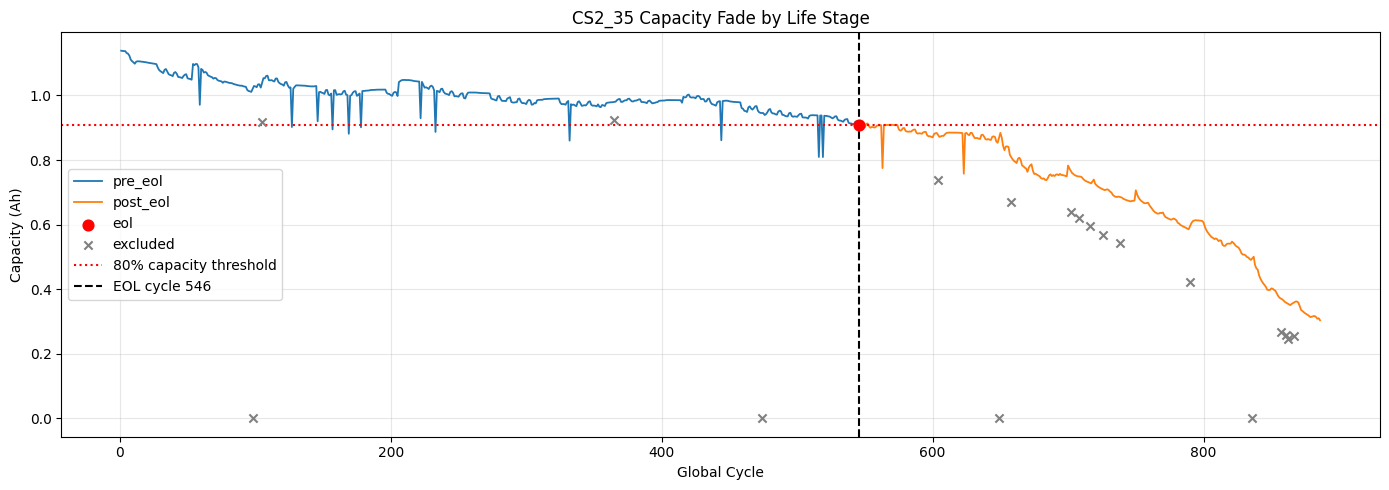

In [10]:
STAGE_COLORS = {
    "pre_eol": "tab:blue",
    "eol": "red",
    "post_eol": "tab:orange",
}

plt.figure(figsize=(14, 5))

for stage in [
    "pre_eol",
    "post_eol",
]:
    stage_df = battery_cycles[
        battery_cycles["life_stage"]
        == stage
    ]

    plt.plot(
        stage_df["cycle"],
        stage_df["capacity_ah"],
        color=STAGE_COLORS[stage],
        linewidth=1.3,
        label=stage,
    )

plt.scatter(
    eol_cycles["cycle"],
    eol_cycles["capacity_ah"],
    color=STAGE_COLORS["eol"],
    s=60,
    label="eol",
    zorder=4,
)

plt.scatter(
    excluded_cycles["cycle"],
    excluded_cycles["capacity_ah"],
    color="gray",
    marker="x",
    s=35,
    label="excluded",
    zorder=3,
)

plt.axhline(
    initial_capacity * eol_threshold,
    color="red",
    linestyle=":",
    label="80% capacity threshold",
)

plt.axvline(
    eol_cycle,
    color="black",
    linestyle="--",
    label=f"EOL cycle {eol_cycle}",
)

plt.title("CS2_35 Capacity Fade by Life Stage")
plt.xlabel("Global Cycle")
plt.ylabel("Capacity (Ah)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

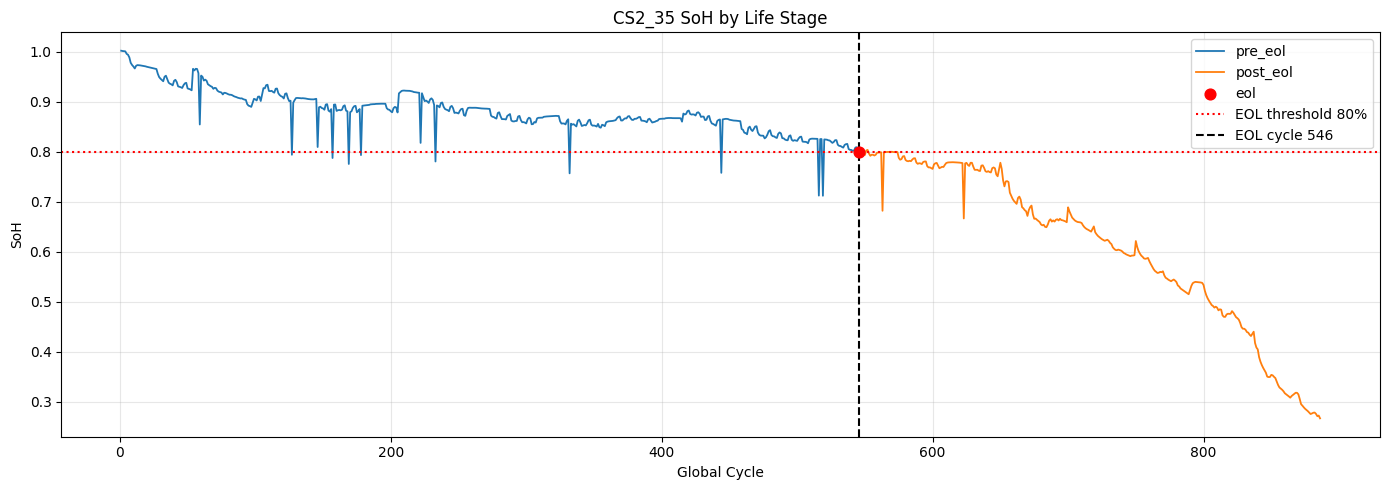

In [11]:
plt.figure(figsize=(14, 5))

for stage in [
    "pre_eol",
    "post_eol",
]:
    stage_df = battery_cycles[
        battery_cycles["life_stage"]
        == stage
    ]

    plt.plot(
        stage_df["cycle"],
        stage_df["soh"],
        color=STAGE_COLORS[stage],
        linewidth=1.3,
        label=stage,
    )

plt.scatter(
    eol_cycles["cycle"],
    eol_cycles["soh"],
    color=STAGE_COLORS["eol"],
    s=60,
    label="eol",
    zorder=4,
)

plt.axhline(
    eol_threshold,
    color="red",
    linestyle=":",
    label="EOL threshold 80%",
)

plt.axvline(
    eol_cycle,
    color="black",
    linestyle="--",
    label=f"EOL cycle {eol_cycle}",
)

plt.title("CS2_35 SoH by Life Stage")
plt.xlabel("Global Cycle")
plt.ylabel("SoH")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

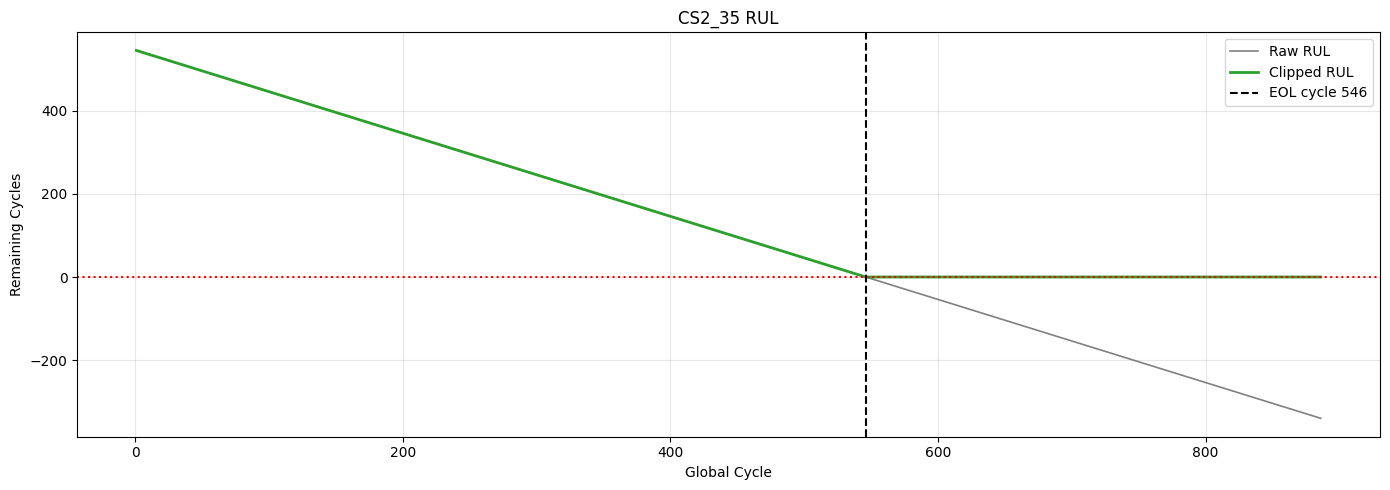

In [12]:
plt.figure(figsize=(14, 5))

plt.plot(
    modeling_cycles["cycle"],
    modeling_cycles["rul"],
    color="gray",
    linewidth=1.2,
    label="Raw RUL",
)

plt.plot(
    modeling_cycles["cycle"],
    modeling_cycles["rul_clipped"],
    color="tab:green",
    linewidth=2,
    label="Clipped RUL",
)

plt.axhline(
    0,
    color="red",
    linestyle=":",
)

plt.axvline(
    eol_cycle,
    color="black",
    linestyle="--",
    label=f"EOL cycle {eol_cycle}",
)

plt.title("CS2_35 RUL")
plt.xlabel("Global Cycle")
plt.ylabel("Remaining Cycles")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
display_columns = [
    "cycle",
    "capacity_ah",
    "soh",
    "eol_cycle",
    "rul",
    "rul_clipped",
    "post_eol",
    "life_stage",
    "cycle_type",
    "is_modeling_cycle",
]

display(
    battery_cycles[
        battery_cycles["cycle"].between(
            eol_cycle - 5,
            eol_cycle + 10,
        )
    ][display_columns]
)

display(
    battery_cycles[
        display_columns
    ].tail(20)
)

,cycle,capacity_ah,soh,eol_cycle,rul,rul_clipped,post_eol,life_stage,cycle_type,is_modeling_cycle
540,541,0.911196,0.801811,546,5,5,False,pre_eol,standard_full_cycle,True
541,542,0.911760,0.802308,546,4,4,False,pre_eol,standard_full_cycle,True
542,543,0.918676,0.808393,546,3,3,False,pre_eol,standard_full_cycle,True
543,544,0.919322,0.808961,546,2,2,False,pre_eol,standard_full_cycle,True
544,545,0.915469,0.805572,546,1,1,False,pre_eol,standard_full_cycle,True
545,546,0.908205,0.799180,546,0,0,False,eol,standard_full_cycle,True
546,547,0.905165,0.796504,546,-1,0,True,post_eol,standard_full_cycle,True
547,548,0.908010,0.799008,546,-2,0,True,post_eol,standard_full_cycle,True
548,549,0.904317,0.795758,546,-3,0,True,post_eol,standard_full_cycle,True
549,550,0.901716,0.793469,546,-4,0,True,post_eol,standard_full_cycle,True


,cycle,capacity_ah,soh,eol_cycle,rul,rul_clipped,post_eol,life_stage,cycle_type,is_modeling_cycle
866,867,0.256309,NaN,546,<NA>,<NA>,<NA>,excluded,nonstandard_cycle,False
867,868,0.361723,0.318300,546,-322,0,True,post_eol,standard_full_cycle,True
868,869,0.361648,0.318234,546,-323,0,True,post_eol,standard_full_cycle,True
869,870,0.358120,0.315129,546,-324,0,True,post_eol,standard_full_cycle,True
870,871,0.347464,0.305752,546,-325,0,True,post_eol,standard_full_cycle,True
871,872,0.335722,0.295420,546,-326,0,True,post_eol,standard_full_cycle,True
872,873,0.332357,0.292459,546,-327,0,True,post_eol,standard_full_cycle,True
873,874,0.328566,0.289123,546,-328,0,True,post_eol,standard_full_cycle,True
874,875,0.325232,0.286190,546,-329,0,True,post_eol,standard_full_cycle,True
875,876,0.322707,0.283967,546,-330,0,True,post_eol,standard_full_cycle,True


In [14]:
analysis_columns = [
    "post_eol",
    "life_stage",
]

base_columns = [
    column
    for column in battery_cycles.columns
    if column not in analysis_columns
]

battery_cycles_analysis = battery_cycles[
    base_columns + analysis_columns
].copy()

assert battery_cycles_analysis.shape == (
    886,
    40,
)

CSV_OUTPUT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

PARQUET_OUTPUT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

battery_cycles_analysis.to_csv(
    CSV_OUTPUT_PATH,
    index=False,
)

battery_cycles_analysis.to_parquet(
    PARQUET_OUTPUT_PATH,
    index=False,
)

csv_check = pd.read_csv(
    CSV_OUTPUT_PATH
)

parquet_check = pd.read_parquet(
    PARQUET_OUTPUT_PATH
)

assert csv_check.shape == parquet_check.shape
assert list(csv_check.columns) == list(
    parquet_check.columns
)

assert np.allclose(
    csv_check["soh"],
    parquet_check["soh"],
    equal_nan=True,
)

print("CSV shape:", csv_check.shape)
print("Parquet shape:", parquet_check.shape)
print("04 outputs are consistent.")

CSV shape: (886, 40)
Parquet shape: (886, 40)
04 outputs are consistent.
